Linear Fit:     MSE=0.061400, R²=0.967102
Cubic Polyfit:  MSE=0.004829, R²=0.997413
Cubic polynomial fits better (lower MSE).


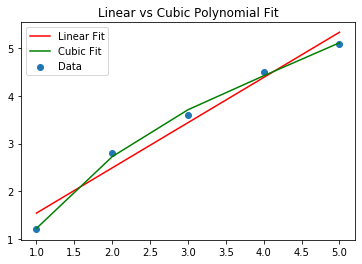

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def mse(y, y_pred):
    return np.mean((y - y_pred)**2)

def r2(y, y_pred):
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res/ss_tot

X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_lin_pred = m*X + c

mse_lin = mse(Y, Y_lin_pred)
r2_lin = r2(Y, Y_lin_pred)

coeffs_cubic = np.polyfit(X, Y, 3)
Y_cubic_pred = np.polyval(coeffs_cubic, X)

mse_cubic = mse(Y, Y_cubic_pred)
r2_cubic = r2(Y, Y_cubic_pred)

print(f"Linear Fit:     MSE={mse_lin:.6f}, R²={r2_lin:.6f}")
print(f"Cubic Polyfit:  MSE={mse_cubic:.6f}, R²={r2_cubic:.6f}")

if mse_cubic < mse_lin:
    print("Cubic polynomial fits better (lower MSE).")
else:
    print("Linear least squares fits better (lower MSE).")

plt.figure()
plt.scatter(X, Y, label="Data")
plt.plot(X, Y_lin_pred, label="Linear Fit", color="red")
plt.plot(X, Y_cubic_pred, label="Cubic Fit", color="green")
plt.legend()
plt.title("Linear vs Cubic Polynomial Fit")
plt.show()

In [ ]:
print("\n=== Part B: Polynomial Degree Sweep ===")

degrees = range(1, 11)  # 1 through 10
results = []

for deg in degrees:
    coeffs = np.polyfit(X, Y, deg)
    Y_pred = np.polyval(coeffs, X)

    mse_val = mse(Y, Y_pred)
    r2_val = r2(Y, Y_pred)

    results.append((deg, mse_val, r2_val))
    print(f"Degree {deg}: MSE={mse_val:.6f}, R²={r2_val:.6f}")

    # Plot each fit
    x_dense = np.linspace(min(X), max(X), 200)
    y_dense = np.polyval(coeffs, x_dense)

    plt.figure()
    plt.scatter(X, Y)
    plt.plot(x_dense, y_dense)
    plt.title(f"Polynomial Degree {deg}")
    plt.show()

# Identify overfit and underfit
best_deg = min(results, key=lambda x: x[1])[0]
print(f"\nBest degree by MSE: {best_deg}")

# Underfit = lowest degree with noticeably poor R²
underfit_deg = min(results, key=lambda x: x[2])[0]
print(f"Most underfit degree (lowest R²): {underfit_deg}")